# Calcium imaging analysis! 
Note that your files must follow this format: <br>
- Each column = Individual cell/ROI (Separate column for time optional, but if included, MUST be first column) <br>
- Each row = Acquisition number (each "frame" from your calcium imaging recording). Row 1 MUST be the "names" of the cells (aka you need a header row) <br> 
- If you want to include the areas of the ROIs, make sure this is the <b>last row</b> of your file <br>
- If using Fura-2, data should be pre-calculated ratios (340nm/380nm) <br>

Run each code block in sequence, one at a time, using shift+return or the play button at the top of the notebook.

## Package import

In [1]:
import numpy as np
import pandas as pd
import glob, os
import os.path #to define a path for a specific folder
import scipy as sp
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
import tkinter as tk
from tkinter import filedialog, ttk
from tkinter import *
from pathlib import Path
from matplotlib import pyplot as plt
from scipy.signal import find_peaks, peak_widths
from scipy import stats
from numpy import trapz
from sklearn.preprocessing import normalize, minmax_scale
import warnings
from contextlib import contextmanager

In [2]:
%load_ext rpy2.ipython
#this magic tool lets you use R in this notebook alongside python! So cool

## Select files you want to analyze
If you are loading in multiple files, the file "number" will be in the order that you loaded it in. <br>

E.g., if you load in file x, file y, and file z, their "number" will be as follows: <br>
    file x = 0 (python starts counting from 0) <br>
    file y = 1 <br>
    file z = 2 <br>

This is important if you want to edit individual files within this code!

In [294]:
#See what your current working directory is. If you are already in the directory you want to be in, SKIP the next step
os.getcwd() 

'/Users/Dragonweaver/Documents/Grad School Stuff/Calcium imaging'

In [ ]:
#set your desired working directory (where you want your results folder to go) 
os.chdir("insert/path/name/")

In [295]:
#set/create the directory that your result files will go into 
output_dir = "peak_data_output/Final/" 
os.makedirs(output_dir, exist_ok=True) 

In [1221]:
def select_files(title="Select files", filetypes=(("CSV files", "*.csv"), ("All files", "*.*"))):
    root = tk.Tk()
    root.update()            # Fix macOS focus issue

    file_paths = filedialog.askopenfilenames(
        title=title,
        filetypes=filetypes
    )

    root.destroy()           # Properly close Tk instance
    return list(file_paths)
    
files = select_files()

dfs = {} # Load each file into its own DataFrame

for file in files:
    name = Path(file).stem  # filename without extension
    dfs[name] = pd.read_csv(file) #select and load in your csv files into a dictionary
    #dfs[name] = np.asarray(dfs[name]) #turns your csv file into an array -- needed for downstream analysis
    data = list(dfs.values())
print("Loaded files:")
for name in dfs:
    print(name)

Loaded files:
WTMouse_AllDRG_Control


In [735]:
#you can now list each variable as dfs["Name_of_file"]. Test it out here!
dfs["All_DRGAnalysis_GDNF"]

KeyError: 'All_DRGAnalysis_GDNF'

## Select columns per file to analyze
For link_zones, this checkbox is for if all the files you are analyzing have the same stimulation times <br>
If the <b>final row</b> of your file is the Area of the ROIs, tick the "Includes Areas Row" box.

In [1222]:
%matplotlib widget
# Global variables
link_zones = True
time_col = False
areas_row = True
names = [list(dfs.keys())[i] for i in range(0, len(data))]
# Create region columns widgets
columns_widgets = [widgets.SelectMultiple(options=[], description='Region cols',
                            disabled=False, layout={'width':'160px', 'height':'120px'}, style={'description_width':'100px'})
                  for i in range(0, len(data))]

#If your data file has a separate column for time/acquisition number, check for yes
included_widgets = [widgets.Checkbox(value=time_col, description='Includes a Time Col',
                                  disabled=False, indent=False)
                    for i in range(0,len(data))]
areas_widgets = [widgets.Checkbox(value = areas_row, description = "Includes Areas Row", disabled = False, indent = False)
                 for i in range(0, len(data))]

for i in range(0, len(data)):
    
    # Create label widgets
    label_widgets = [widgets.Label("Columns to analyze for " + names[i] + ":") for i in range(0, len(data))]
    print("Note that by default all columns are selected for each data file")
    cols = data[i].shape[1]
    columns_widgets[i].options = range(0,cols)
    columns_widgets[i].value = columns_widgets[i].options
    col_widg = widgets.VBox(children=[label_widgets[i],columns_widgets[i], included_widgets[i], areas_widgets[i]])
    display(col_widg)
    
# Widget to ask use if want to use the same stimulation zones
link_widget = widgets.Checkbox(value=link_zones, description='Check this box to make stimulation zones the same for all files',
                               disabled=False, indent=False, layout={'width':'400px'})
print("OPTION TO MAKE STIMULATION ZONES SAME FOR ALL FILES")
display(link_widget)


Note that by default all columns are selected for each data file


OPTION TO MAKE STIMULATION ZONES SAME FOR ALL FILES


Checkbox(value=True, description='Check this box to make stimulation zones the same for all files', indent=Fal…

## Calculate and enter frame rate of acquisitions

In [1226]:
Framerate = 0.5 #how many acquisitions per second. e.g., 1 acquisition every 2 seconds = Framerate of 0.5

## Plot all your traces

In [1227]:
timecol = [included_widgets[i].value for i in range(0, len(data))]
areasrow = [areas_widgets[i].value for i in range(0, len(data))]
link_zones = link_widget.value
style = {'description_width': 'initial'}
num_stim_widgets = [widgets.IntText(
    value=0,
    description='# of Stimulations (including KCl):', style=style) for i in range(0, len(data))]

#define a function for if you have/don't have a time column and/or areas row
#cleans up the code a bit and prevents the need to do a bunch of "if elif elif else" statements!

def file_formats(df, time_col=timecol, areas_row = areasrow):
    if time_col[i] == True and areas_row[i] == True:
        return df[:-1, 1:]
    elif time_col[i] == True:
        return df[:,1:]
    elif areas_row[i] == True:
        return df[0:-1]
    else:
        return df

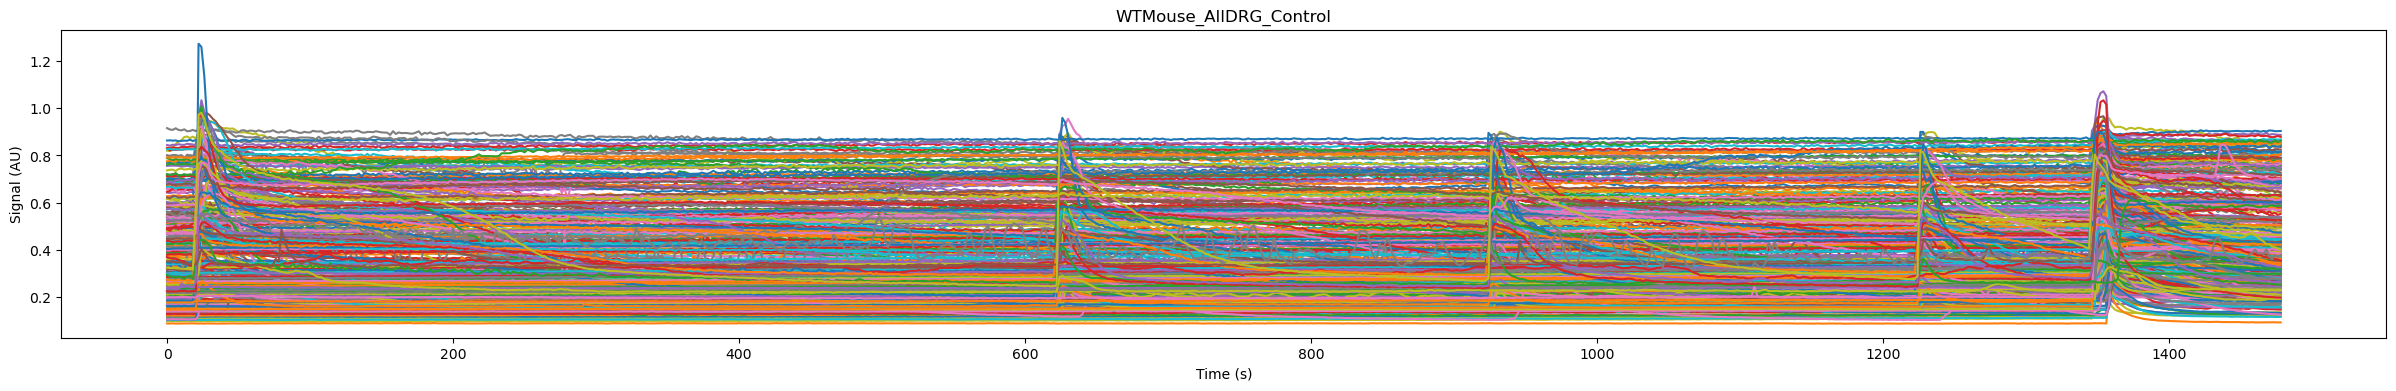

IntText(value=0, description='# of Stimulations (including KCl):', style=DescriptionStyle(description_width='i…

In [1228]:
%matplotlib inline

cols_selected = [np.array(columns_widgets[i].value) for i in range(0, len(data))]
reshaped_data = {}
for i in range(0,len(data)):
    
    reshaped_data[i] = pd.DataFrame(file_formats(data[i].iloc[:,cols_selected[i]]))
    
    fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(30,4), constrained_layout=False)
    ax.set_title(names[i])
    ax.set(ylabel="Signal (AU)")
    ax.set(xlabel="Time (s)")
    ax.plot((reshaped_data[i].index/Framerate), reshaped_data[i]) #X axis takes the framerate and converts to seconds
    plt.show()
        
    if link_zones == False:
        display(num_stim_widgets[i]) #one stim_widget per file 

if link_zones == True:
    display(num_stim_widgets[-1]) #one stim_widget for all files

## Remove non-neuronal and dead cells
Play around with your parameters for what you want to be considered a peak and return to baseline! <br>
Just make sure you keep these parameters consistent between files.

In [1229]:
#Global variables

KCl_start = 670 #acquisition number when KCl application starts
KCl_end = 690 #acquisition number when KCl response ends
KCl_baseline_start = 650 #when you want to start collecting your pre-KCl baseline
KCl_baseline_end = 670 #when you want to stop collecting your pre-KCl baseline
KCl_baseline_return = 735 #acquisition number where your trace should return to pre-KCl baseline 
prominence_mult = 1.0 #what percent over baseline the KCl peak must be to be considered a response
baseline_pad = .85 #what percent of the baseline the response must return to in order to be considered "recovered" from KCl 
                    #(aka the cell is still alive)

In [1230]:
neuron_data = []

for i in range(0, len(data)):
    dataset_baseline = reshaped_data[i].values[KCl_baseline_start:KCl_baseline_end].mean(axis=0)
    dataset_peak_pad = dataset_baseline * prominence_mult #anything at or over this value is considered a KCl response
    dataset_peak = reshaped_data[i][KCl_start:KCl_end].max(axis=0)
    dataset_return_baseline = reshaped_data[i].values[KCl_end:KCl_baseline_return].mean(axis=0)
    dataset_return_baseline_pad = dataset_baseline * baseline_pad
    
    # Boolean mask: keep cells where peak > baseline_pad
    KCl_peaks = dataset_peak >= dataset_peak_pad 
    KCl_recover = dataset_return_baseline >= dataset_return_baseline_pad
    neurons = KCl_peaks & KCl_recover == True
    
    # Append filtered DataFrame to new list
    neuron_data.append(reshaped_data[i].loc[:, neurons])

## Input number of stimulations 
Put the <b>acquisition number</b> of your stimulations <br>
If you're analyzing a lot of files at the same time, you will need to scroll to see the widget!

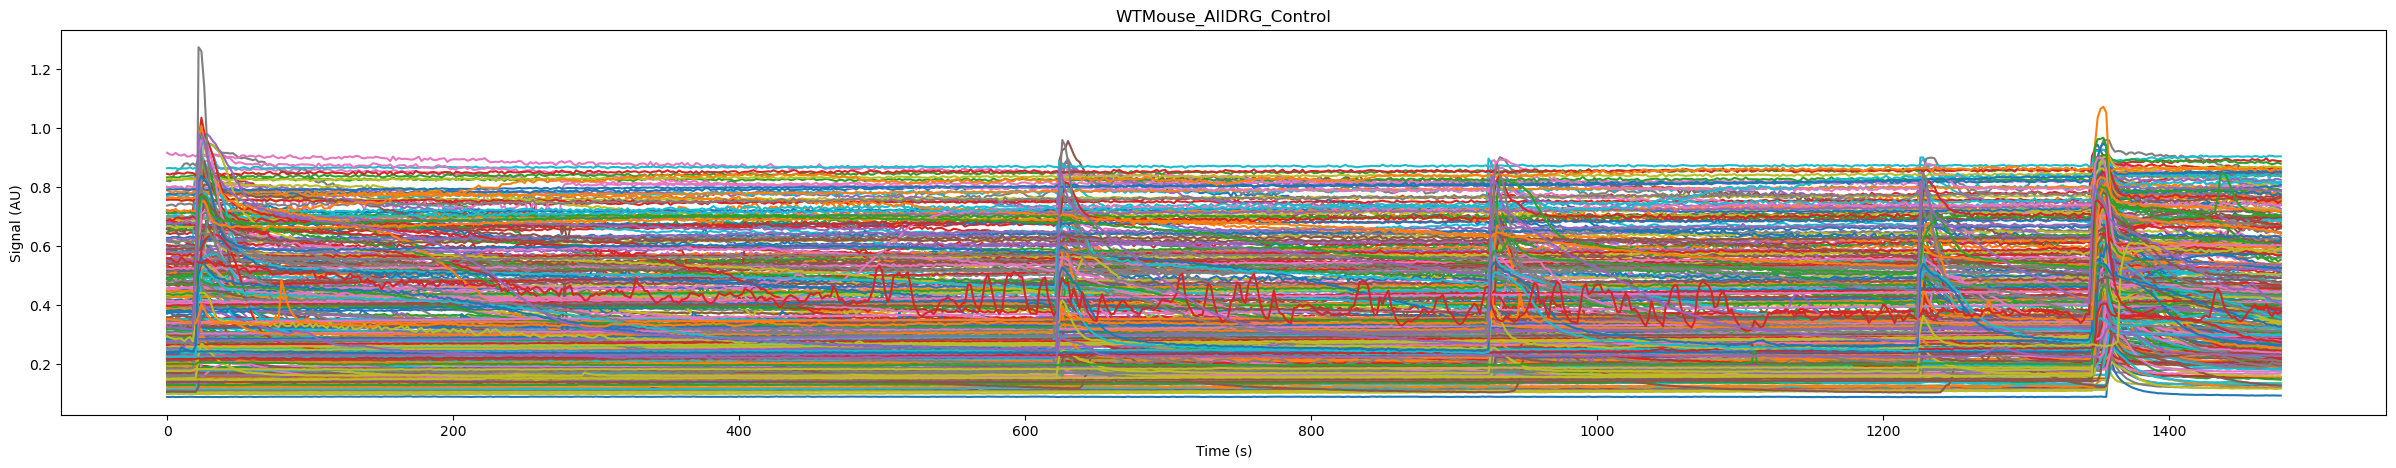

IntText(value=0, description='Stimulation 0:', style=DescriptionStyle(description_width='initial'))

IntText(value=0, description='Stimulation 1:', style=DescriptionStyle(description_width='initial'))

IntText(value=0, description='Stimulation 2:', style=DescriptionStyle(description_width='initial'))

IntText(value=0, description='Stimulation 3:', style=DescriptionStyle(description_width='initial'))

IntText(value=0, description='Stimulation 4:', style=DescriptionStyle(description_width='initial'))

In [1231]:
%matplotlib inline
plt.close('all')

stim_zone_widgets = {}
for i in range(0,len(neuron_data)):
    fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(30,5), constrained_layout=False)
    ax.set_title(names[i])
    ax.set(ylabel="Signal (AU)")
    ax.set(xlabel="Time (s)")
    ax.plot((neuron_data[i].index / Framerate), neuron_data[i].values) #X axis takes the framerate and converts to seconds
    plt.show()
        
    if link_zones == False:
        stim_zone_widgets[i] = [widgets.IntText(value=0,
                                         description=f'Stimulation {j}:',
                                         style=style)
                         for j in range(0, num_stim_widgets[i].value)]
        for widget in stim_zone_widgets[i]:
            display(widget)

    elif link_zones == True:
        stim_zone_widgets['linked'] = [widgets.IntText(value=0,
                                      description=f'Stimulation {j}:',
                                      style=style)
                      for j in range(0, num_stim_widgets[i].value)]
        for widget in stim_zone_widgets['linked']:
            display(widget)

In [1232]:
#define stim zones so we can use the same variable regardless of if the zones are linked or not

def num_stims(i):
    if link_zones == False:
        return num_stim_widgets[i].value
    else:
        return num_stim_widgets[-1].value
        
def stim_zones(i):
    if link_zones == False:
        return [int(w.value) for w in stim_zone_widgets[i]]
    else:
        return [int(w.value) for w in stim_zone_widgets['linked']]

## Remove cells that take too long to return to baseline after stimulus
If you do not need this step, just set recovery_window_seconds to your entire recording time. 

In [1233]:
#Global variables
recovery_window_seconds = 600 #max time (seconds) the cell can respond for until it must be removed
recovery_window_frames = int(recovery_window_seconds * Framerate)

stim_of_interest = 0 #which stimulation are you measuring? 
                    # *Remember Python starts counting at 0, so just follow stimulation naming convention from previous step*

baseline_begin = 9 #how many acquisitions prior to the stimulus you want to start collecting your baseline recording
baseline_end = 3 #how many acquisitions prior to the stimulus you want to STOP collecting your baseline recording
baseline_mult = 1.50  #what % of baseline mean cell must return to in order to be kept

In [1234]:
plt.close('all') #Frees up memory

filtered_data = []
for i in range(0, len(neuron_data)):
    baseline_start = stim_zones(i)[stim_of_interest] - baseline_begin
    baseline_stop = stim_zones(i)[stim_of_interest] - baseline_end
    neurons_baseline = neuron_data[i].values[baseline_start:baseline_stop].mean(axis=0)
    neurons_baseline_pad = neurons_baseline * baseline_mult
    peak_frame_indices = neuron_data[i][baseline_stop:(baseline_stop + recovery_window_frames)].values.argmax(axis=0) + baseline_stop

    valid_cells = []
    for j, col in enumerate(neuron_data[i].columns):
        peak_frame = peak_frame_indices[j]
        recovery_end_frame = min(peak_frame + recovery_window_frames, len(neuron_data[i]))
    
        # Slice the trace from peak to 90s later
        post_peak_trace = neuron_data[i][col].values[peak_frame:recovery_end_frame]
    
        # Check if trace drops back to within 20% of baseline mean
        returned_to_baseline = (post_peak_trace <= neurons_baseline_pad[j]).any()
        valid_cells.append(returned_to_baseline)
    
    valid_cells = pd.Series(valid_cells, index=neuron_data[i].columns)
    filtered_data.append(neuron_data[i].loc[:, valid_cells])

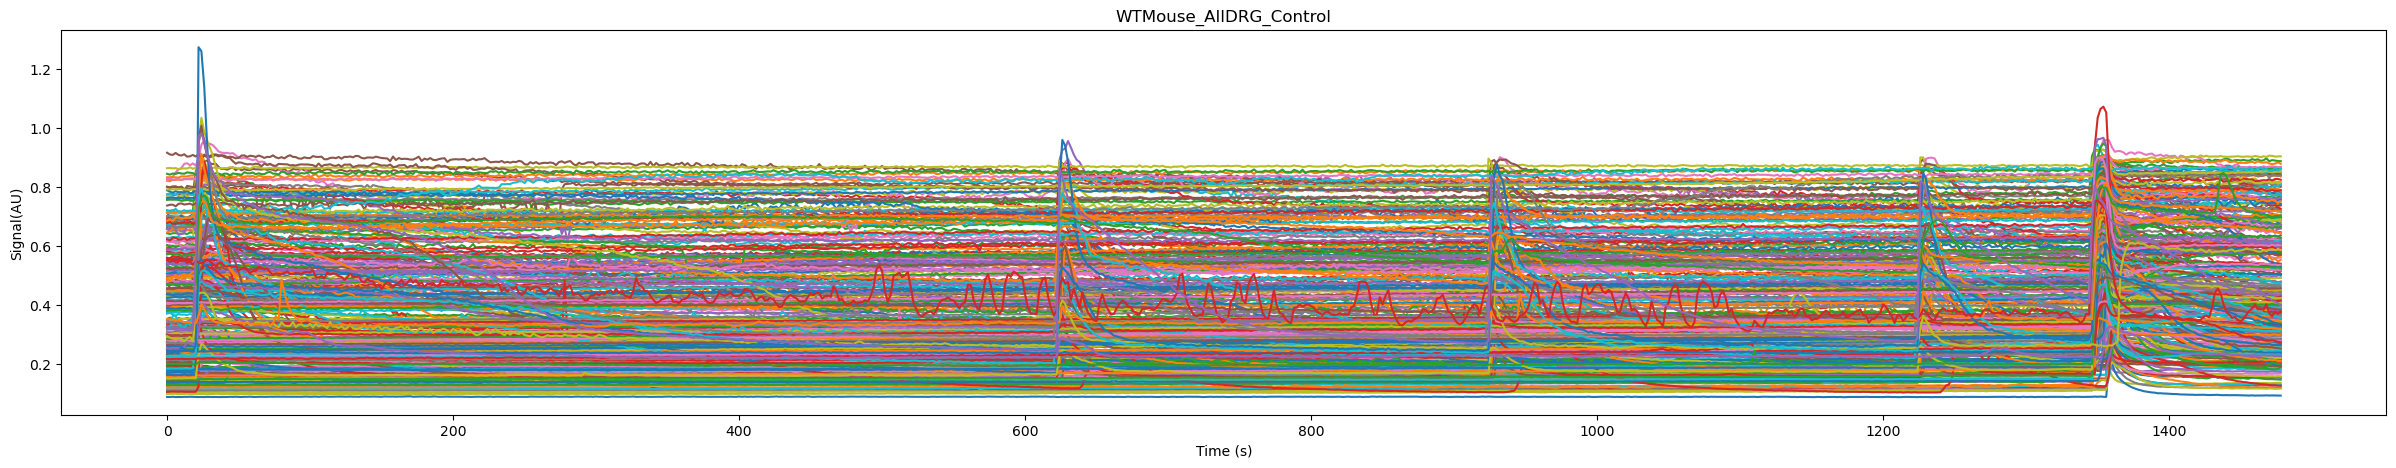

In [1235]:
for i in range(0,len(filtered_data)):
    fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(30,5), constrained_layout=False)
    ax.set_title(names[i])
    ax.set(ylabel="Signal(AU)")
    ax.set(xlabel="Time (s)")
    ax.plot((filtered_data[i].index / Framerate), filtered_data[i].values) #X axis takes the framerate and converts to seconds
    plt.show()
    plt.close() # Frees up memory

## Pull out cells that respond to stimulus

In [1236]:
#Global variables
responder_stimulus = 0 #which stimulation number your interested in measuring a response to 
stimulus_end = 7 #number of acquisitions after stimulus onset where you want to analyze for a peak/response
responder_peak = 1.1 #what % above the baseline a peak must be to be considered a response to stimulus

In [1237]:
responders = []

for i in range(0, len(filtered_data)):
    stimulus_start = int(stim_zones(i)[responder_stimulus])
    baseline = filtered_data[i].values[baseline_start:baseline_end].mean(axis=0)
    baseline_pad = baseline * responder_peak
    response_peak = filtered_data[i][stimulus_start:(stimulus_start+stimulus_end)].max(axis=0)
    
    responding_neurons = response_peak > baseline_pad
    
    # Append filtered DataFrame to new list
    responders.append(filtered_data[i].loc[:, responding_neurons])

## Get average traces of your responders
For traces, we will use the min-max normalization method: (F - Fmin)/(Fmax-Fmin)

In [1238]:
#normalize your responder data (min-max method); ONLY GOOD FOR REPRESENTATIVE TRACES!
normalized_responders_traces = []
for i in range(0,len(responders)):
    data_norm = (responders[i]-responders[i].min())/(responders[i].max()-responders[i].min()) 
    normalized_responders_traces.append(data_norm)

In [1239]:
prominence_peaks = 0.1 #how prominent your peaks are compared to the surrounding area/baseline. Adjust your prominence as needed to change peak detection sensitivity
height_peaks = 0.05 #what y-value/amplitude your peak should reach in order to be considered a peak
dx_framerate = 2 #how many seconds pass per acquisition (e.g., 1 frame per 2 seconds, dx_framerate = 2)
stim_length = 1 #how many acquisitions your stimulus is applied for
stimulus = 'Capsaicin' #enter what your stimulus is. This might take a little tinkering if you have multiple stimuli! 

#only applicable if you applied a treatment:
treatment_label = 'GDNF'
treatment_start = 11/Framerate
treatment_end = 221/Framerate

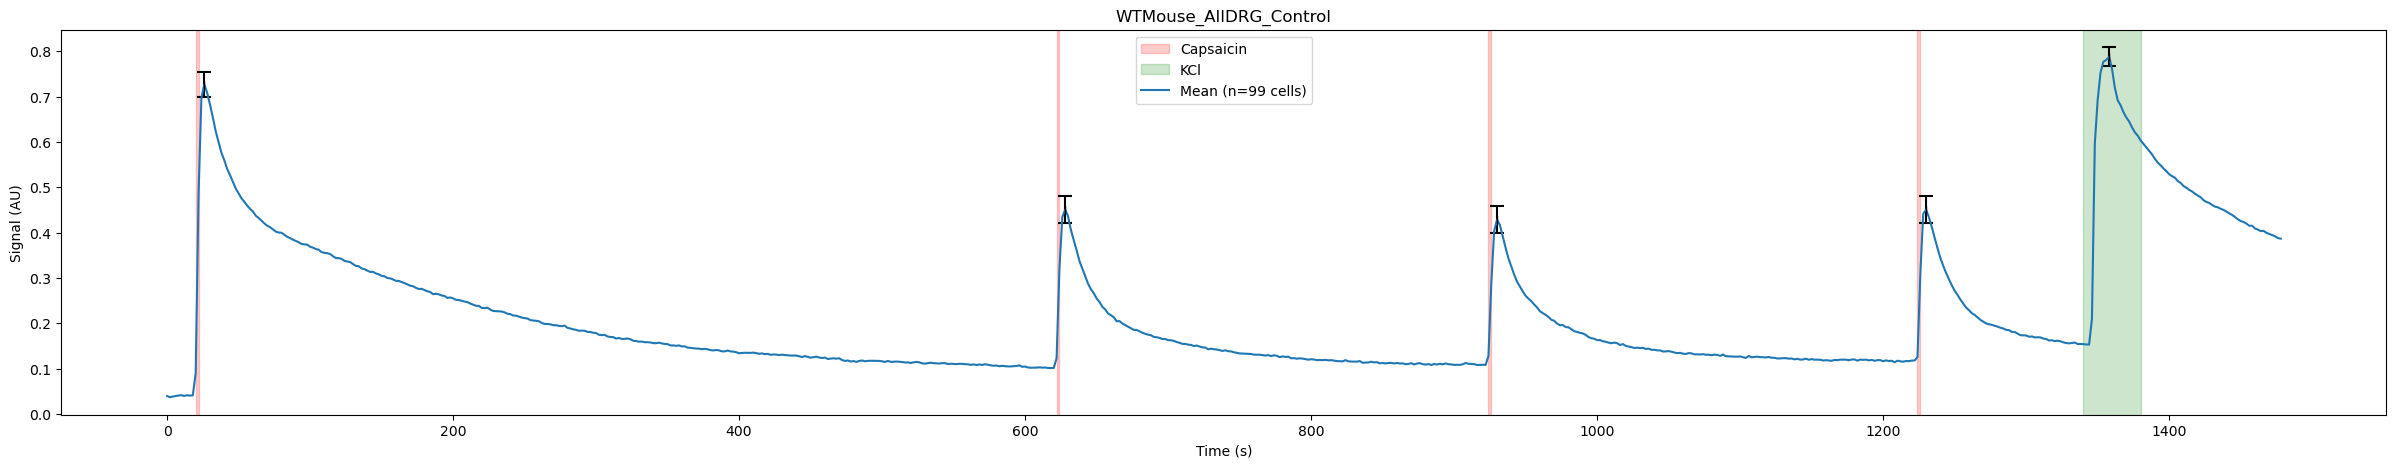

In [1240]:
avg_responses = []
sem_responses = []
peaks = []
properties = []
for i in range(0,len(responders)):
    avg_responses.append(np.array(normalized_responders_traces[i].mean(axis=1))) #average all your responder traces
    sem_responses.append(np.array(normalized_responders_traces[i].sem(axis=1))) #find standard deviation of all responder traces
    n = normalized_responders_traces[i].shape[1]
    
    peaks, properties = find_peaks(avg_responses[i], prominence = prominence_peaks, height = height_peaks) #finds the peaks
        
    fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(30,5), constrained_layout=False)
    ax.set_title(names[i])
    ax.set(ylabel="Signal (AU)")
    ax.set(xlabel="Time (s)")
    ax.errorbar(peaks/Framerate, avg_responses[i][peaks],
                yerr=sem_responses[i][peaks],
                fmt='k|', #makes the error bars black (k) and puts a vertical line to mark where the peak is 
                #couldn't figure out a way to not make it mark the peak, so | it is lol
                capsize=5,
                capthick=1.5)

    for j in range(0, num_stims(i)):
        stim_start = stim_zones(i)[j] / Framerate
        stim_end = (stim_zones(i)[j] + stim_length) / Framerate
        #add when the stimulations are applied
        ax.axvspan(stim_start,  stim_end,
                   alpha=0.2, color='red' if j!=4 else 'none', label = stimulus if j==0 else '') 
        
        """since all of my stims are the same stimulus outside of my final stim (Stim4), I want everything EXCEPT for Stim4 to be labelled
        red. You can also use this method to label all but your KCl peak if you use the same stimulus multiple times
        
        If you have multiple different stimuli and want to label all of them separately, uncomment, repeat and change the following as many
        times as needed. Replace 'n' with the stimulation number for that stimulus:"""
        
        #ax.axvspan(stim_start,  stim_end,
        #            alpha=0.2, color='color' if j==n else 'none', label = 'stimulus' if j==n else '')

    """The line below adds a horizontal line on your graph for when you applied a treatment, if applicable."""
   # ax.hlines(y=0.8, xmin=treatment_start, xmax=treatment_end, linewidth = 2, alpha = 1, color='k', label = treatment_label)
    
    ax.axvspan(KCl_start / Framerate, KCl_end / Framerate, alpha = 0.2, color = 'green', label = 'KCl') #adds when your KCl is applied
    ax.plot((normalized_responders_traces[i].index / Framerate), avg_responses[i], label = f'Mean (n={n} cells)')
    ax.legend(loc = "upper center")
    fig.savefig(os.path.join(output_dir, f"{names[i]}_plot.pdf")) #saves the plots to your directory
    plt.show()
    plt.close() # Frees up memory


## Normalize for statistical analysis
<b>This is different from the normalization used to create the representative traces!</b> <br>
For statistical analysis, we will use ΔF/F0, with ΔF = F-F0 and F0 = baseline before each peak. <br>

<u>Workflow:</u> <br>
 - Detect each local peak in a post-stimulus window <br> 
 - Normalize each cell/column peak to its pre-peak baseline (accounts for baseline drift) <br>
 - Find the width and area under the curve (auc) of each peak per cell <br>
 - Remove outlier cells <br>
 - Average peak heights and auc across all cells (you will get one value per peak per file)
 - Export desired data into a csv file

In [1139]:
#Global variables

#how many acquisitions before each peak you want to start collecting baseline value
peak_baseline_begin = 10 

#how many acquistions before each peak you want to STOP collecting baseline value
peak_baseline_end = 1 

#if you're applying a treatment after a stimulus, enter which stimulus is given before treatment
#alternatively, if you want to compare fold changes of peaks to a control peak/stimulus, enter that stimulus number here
control_stimulus = 0

KCl_stimulus = 4

#For how many acquistions after each stimulus you want to find a response peak
stim_window = 30

#how much of the peak height you want to include in auc calculation. 0.5 = from the half-width point, 1 = full height of the peak
#this number MUST be between 0 and 1
width_baseline_height = 0.5 

In [1140]:
cell_results = {}

for i in range(0, len(responders)):
    all_cell_dff = []
    all_cell_aucs = []
    stim_frames = stim_zones(i)
    
    for cell in range(responders[i].shape[1]):
        per_cell_trace = responders[i].iloc[:, cell].to_numpy() #turn each column/cell into its own array

        cell_peak_frames = []
        peak_dff_per_cell = []
        baseline_per_peak_per_cell = []
        auc_per_cell = []
        for j, stim_frame in enumerate(stim_frames):
            stim_frame_padding = stim_frame + stim_window

            #after each stimulation, find the local peak
            peaks_per_cell = np.argmax(per_cell_trace[stim_frame:stim_frame_padding]) 
            peak_frame_per_cell = stim_frame + peaks_per_cell
            
            cell_peak_frames.append(np.array(peak_frame_per_cell))

            #using baseline window, find the avg baseline (F0) prior to each stimulation/peak
            peaks_baseline_start = stim_frame - peak_baseline_begin
            peaks_baseline_stop = stim_frame - peak_baseline_end

            F0_per_peak = per_cell_trace[peaks_baseline_start:peaks_baseline_stop].mean(axis=0)
            F_per_peak = per_cell_trace[peak_frame_per_cell]
            normalized_peaks_per_cell = (F_per_peak - F0_per_peak) / F0_per_peak
            
            peak_dff_per_cell.append(normalized_peaks_per_cell)
            baseline_per_peak_per_cell.append(F0_per_peak)

        #Find the widths of each detected peak per cell
        widths, width_height, left_ips, right_ips = peak_widths(per_cell_trace, cell_peak_frames, rel_height=width_baseline_height)

        #calculate auc of each peak
        for p in range(0, len(cell_peak_frames)):
        
        #Convert left and right boundaries from peak_widths function into peak window indices
            left_idx = int(np.floor(left_ips[p]))
            right_idx = int(np.ceil(right_ips[p]))

            #take a slice of each peak between each boundary and normalize with (F - F0)/F0
            peak_slice_dff = (per_cell_trace[left_idx:right_idx] - baseline_per_peak_per_cell[p]) / (baseline_per_peak_per_cell[p])

            #np.trapz integrates using the trapezoidal rule
            cell_aucs = np.trapezoid(peak_slice_dff, dx=dx_framerate)
            auc_per_cell.append(cell_aucs)
    
            #collate all information into a dictionary
            all_cell_dff.append({
                "cell": f'cell_{cell}_{names[i]}',
                "peak_height": per_cell_trace[cell_peak_frames][p],
                "stim_idx": "KCl" if p == KCl_stimulus else p,
                "dff": peak_dff_per_cell[p],
                "peak_frame": cell_peak_frames[p],
                #if you don't have treatment, comment the below line out
                "treatment": "pre" if cell_peak_frames[p] <= cell_peak_frames[control_stimulus] else "KCl" if cell_peak_frames[p] == cell_peak_frames[KCl_stimulus] else "post",
                "auc": auc_per_cell[p],
            })
        
    cell_results[i] = all_cell_dff

/var/folders/xr/chxt7nwd2yzdzbm9xwb9l0vm0000gn/T/ipykernel_5319/2152822569.py:36: PeakPropertyWarning: some peaks have a prominence of 0
  widths, width_height, left_ips, right_ips = peak_widths(per_cell_trace, cell_peak_frames, rel_height=width_baseline_height)
/var/folders/xr/chxt7nwd2yzdzbm9xwb9l0vm0000gn/T/ipykernel_5319/2152822569.py:36: PeakPropertyWarning: some peaks have a width of 0
  widths, width_height, left_ips, right_ips = peak_widths(per_cell_trace, cell_peak_frames, rel_height=width_baseline_height)


In [1141]:
#pull out outliers per stim using 1.5x IQR

def dff_outliers(df, value_col, group_col):

    df = df.copy()
    df["dff_outlier"] = False
    
    for group in df[group_col].unique():
        mask = df[group_col] == group
        values = df.loc[mask, value_col]
        
        Q1 = values.quantile(0.25)
        Q3 = values.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df.loc[mask, "dff_outlier"] = (values < lower_bound) | (values > upper_bound)
    
    return df

def auc_outliers(df, value_col, group_col):
    
    df["auc_outlier"] = False
    
    for group in df[group_col].unique(): #only compares peaks within the same stimulations
        mask = df[group_col] == group
        values = df.loc[mask, value_col]
        
        Q1 = values.quantile(0.25)
        Q3 = values.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df.loc[mask, "auc_outlier"] = (values < lower_bound) | (values > upper_bound)
    
    return df


In [1142]:
# Apply per file
no_outliers = {}
valid_indices = []
for i in range(len(responders)):
    df = pd.DataFrame(cell_results[i])
    if df.empty:
        print(f"{names[i]}: skipping — no data")
        continue
        
    df = dff_outliers(df, value_col="dff", group_col="stim_idx")
    df = auc_outliers(df, value_col="auc", group_col="stim_idx")

    #remove the cell only if the peak height AND the auc are outliers
    outlier_cells = df[df["dff_outlier"] & df["auc_outlier"]]["cell"].unique()
    no_outliers[i] = df[~df["cell"].isin(outlier_cells)].to_dict("records")
    valid_indices.append(i)

    n_peak_outliers = df["dff_outlier"].sum()
    n_auc_outliers = df["auc_outlier"].sum()
    print(f"{names[i]}: {n_peak_outliers} peak height outliers and {n_auc_outliers} auc outliers out of {len(df)} cell-peaks")

WT6_DRG_NoAreas_Control: 3 peak height outliers and 14 auc outliers out of 145 cell-peaks


## Export Summarized Data to CSV

In [1143]:
#now we will be aggregating our results per cell, per stimulation, per treatment/ along the columns you are interested in
#If you do not have a treatment, leave that column name out

column_names = ["cell", "treatment", "stim_idx"]

In [1144]:
summary_per_file = {}
for i in valid_indices:
    df = pd.DataFrame(no_outliers[i])
    if df.empty:
        print(f"{names[i]}: skipping — no data")
        continue
        
    control_dff_per_cell = df[df["stim_idx"] == control_stimulus].set_index("cell")["dff"]
    control_auc_per_cell = df[df["stim_idx"] == control_stimulus].set_index("cell")["auc"]
    df["peak_height_fold_change"] = df.apply(lambda row: row["dff"] / control_dff_per_cell[row["cell"]], axis=1)
    df["auc_fold_change"] = df.apply(lambda row: row["auc"] / control_auc_per_cell[row["cell"]], axis=1)
    
    # Average across cells for each stim, within each file
    summary = df.groupby("stim_idx").agg(
        peak_height_mean=("dff", "mean"), #normalized peak heights per peak averaged across all cells in a file 
        peak_height_std=("dff", "std"),
        peak_height_sem=("dff", lambda x: x.std() / np.sqrt(len(x))),
        peak_height_foldchange=("peak_height_fold_change", "mean"),
        auc_mean=("auc", "mean"), #normalized aucs per peak averaged across all cells in a file
        auc_std=("auc","std"),
        auc_sem=("dff", lambda x: x.std() / np.sqrt(len(x))),
        auc_foldchange=("auc_fold_change", "mean")
    ).reset_index()

    
    #get the number of responders and neurons per file
    cell_numbers = pd.DataFrame({'n_responders': [len(responders[i].columns)],
                                'n_neurons': [len(filtered_data[i].columns)],
                                'percent_responders': [len(responders[i].columns)/len(filtered_data[i].columns) * 100],
                                 'file_name': names[i]
                                })

    summary = summary.join(cell_numbers)
    summary_per_file[i] = summary
    output_path = os.path.join(output_dir, f"{names[i]}_average_peak_data.csv")
    summary.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

Saved: peak_data_output/Final/WT6_DRG_NoAreas_Control_average_peak_data.csv


## Export info from individual cells into csv
The previous step gave you the averages of all cells within a stimulation. <br>
However, for statistical analysis of per-cell variability, you may want to also run the next steps.

In [1056]:
every_cell_per_file = {}
for i in valid_indices:
    df = pd.DataFrame(no_outliers[i])
 
    control_dff_per_cell = df[df["stim_idx"] == control_stimulus].set_index("cell")["dff"]
    control_auc_per_cell = df[df["stim_idx"] == control_stimulus].set_index("cell")["auc"]
    df["peak_height_fold_change"] = df.apply(lambda row: row["dff"] / control_dff_per_cell[row["cell"]], axis=1)
    df["auc_fold_change"] = df.apply(lambda row: row["auc"] / control_auc_per_cell[row["cell"]], axis = 1)
    
    # Average across cells for each stim, within each file
    summary = df.groupby(column_names).agg(
        peak_height_mean=("dff", "mean"), #normalized peak heights per peak averaged across all cells in a file 
        peak_height_foldchange=("peak_height_fold_change", "mean"),
        auc_mean=("auc", "mean"), #normalized aucs per peak averaged across all cells in a file
        auc_foldchange=("auc_fold_change", "mean")
    ).reset_index()

    #get the number of responders and neurons per file
    cell_numbers = pd.DataFrame({'n_responders': [len(responders[i].columns)],
                                'n_neurons': [len(filtered_data[i].columns)],
                                'percent_responders': [len(responders[i].columns)/len(filtered_data[i].columns) * 100]
                                })

    summary = summary.join(cell_numbers)
    every_cell_per_file[i] = summary
    output_path = os.path.join(output_dir, f"{names[i]}_every_cell_peak_data.csv")
    summary.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

Saved: peak_data_output/Final/NMR_TG_GDNF_every_cell_peak_data.csv
Saved: peak_data_output/Final/NMR_TG_Control_every_cell_peak_data.csv
Saved: peak_data_output/Final/NMR_DRG_GDNF_every_cell_peak_data.csv
Saved: peak_data_output/Final/NMR_DRG_Control_every_cell_peak_data.csv


## Export all neuron sizes as CSV

In [1057]:
neuron_size_results = []

for i in range(0, len(data)):
    if areasrow[i] == False:
        continue
    else:
        neuron_cols = neuron_data[i].columns
        neuron_sizes = data[i][neuron_cols].iloc[-1]

        responder_cols = responders[i].columns
        non_responder_cols = neuron_cols.difference(responder_cols)

        responder_sizes = neuron_sizes[responder_cols].rename("cell_size").to_frame()
        responder_sizes["group"] = "responder"
        responder_sizes["file"] = names[i]

        non_responder_sizes = neuron_sizes[non_responder_cols].rename("cell_size").to_frame()
        non_responder_sizes["group"] = "non_responder"
        non_responder_sizes["file"] = names[i]

        combined = pd.concat([responder_sizes, non_responder_sizes])
        neuron_size_results.append(combined)

        # Export one CSV per file
        output_path = os.path.join(output_dir, f"{names[i]}_neuron_sizes.csv")
        combined.to_csv(output_path, index=True)
        print(f"Saved: {output_path}")

Saved: peak_data_output/Final/NMR_TG_GDNF_neuron_sizes.csv
Saved: peak_data_output/Final/NMR_TG_Control_neuron_sizes.csv
Saved: peak_data_output/Final/NMR_DRG_GDNF_neuron_sizes.csv
Saved: peak_data_output/Final/NMR_DRG_Control_neuron_sizes.csv


## Statisical Analysis
The next steps prepare your files for analysis in R, which you can use within this notebook

In [920]:
Treatment_condition = -1 #what number word in your file name indicates your treatment condition
Subject = 0 #what number word in your file name indicates your subject/mouse number

In [921]:
combined_files = []
for i in valid_indices:
    df = pd.DataFrame(every_cell_per_file[i])
    combined_files.append(df.assign(file=names[i]))

combined = pd.concat(combined_files)
combined["condition"] = combined["file"].apply(lambda x: x.split("_")[Treatment_condition])
combined["subject"] = combined["file"].apply(lambda x: x.split("_")[Subject])

#now we move everything into R for better statistical analysis

%R -i combined
%R -i output_dir

/opt/anaconda3/envs/ipyV8/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/opt/anaconda3/envs/ipyV8/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "stim_idx". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'str'> and <class 'int'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


In [349]:
%%R
install.packages(c("broom", 
                   "corrr", 
                   "distributional", 
                   "downlit", 
                   "downloadthis", 
                   "ggdist", 
                   "ggResidpanel", 
                   "janitor", 
                   "kableExtra", 
                   "knitr", 
                   "lme4", 
                   "patchwork", 
                   "pwr", 
                   "reticulate", 
                   "rstatix", 
                   "tidyverse", 
                   "lmerTest", 
                   "broom.mixed", 
                   "performance", 
                   "see",
                   "glmmTMB", 
                   "brms", 
                   "MASS", 
                   "RLRsim", 
                   "pbkrtest",
                   "DHARMa",
                  "influence.ME",
                  "mixpower",
                  "rstanarm",
                  "tidybayes",
                  "bestNormalize",
                  "bayesplot"))

trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/broom_1.0.13.tgz'
trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/corrr_0.4.5.tgz'
trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/distributional_0.8.1.tgz'
trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/downlit_0.4.5.tgz'
trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/downloadthis_0.5.0.tgz'
trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/ggdist_3.3.3.tgz'
trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/janitor_2.2.1.tgz'
trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/kableExtra_1.4.1.tgz'
trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/knitr_1.51.tgz'
trying URL 'https://www.stats.bris.ac.uk/R/bin/macosx/big-sur-arm64/contrib/4.5/lme4_2.0-6.tgz'
tryin

RInterpreterError: Failed to parse and evaluate line 'install.packages(c("broom", \n                   "corrr", \n                   "distributional", \n                   "downlit", \n                   "downloadthis", \n                   "ggdist", \n                   "ggResidpanel", \n                   "janitor", \n                   "kableExtra", \n                   "knitr", \n                   "lme4", \n                   "patchwork", \n                   "pwr", \n                   "reticulate", \n                   "rstatix", \n                   "tidyverse", \n                   "lmerTest", \n                   "broom.mixed", \n                   "performance", \n                   "see",\n                   "glmmTMB", \n                   "brms", \n                   "MASS", \n                   "RLRsim", \n                   "pbkrtest",\n                   "DHARMa",\n                  "influence.ME",\n                  "mixpower",\n                  "rstanarm",\n         

In [ ]:
%%R
library(tidyverse)
library(lme4)
library(lmerTest)
library(broom)
library(broom.mixed)
library(patchwork)
library(stringr)
library(magrittr)
library(emmeans)
library(DHARMa)
library(influence.ME)
library(pwr)
library(mixpower)
library(rstanarm)
library(tidybayes)
library(MASS)
library(bestNormalize)
library(brms)
library(bayestestR)
library(performance)
library(bayesplot)

In [960]:
%%R

combined <- data.frame(combined, stringsAsFactors = T)
combined_firstpeaks <- subset(combined, stim_idx <= 1)

combined_firstpeaks$subject_numeric = as.factor(combined_firstpeaks$subject)
combined_firstpeaks$subject_numeric = as.numeric(combined_firstpeaks$subject_numeric)

#summary(combined_firstpeaks)
#combined_firstpeaks

 [1] "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT7" "WT7" "WT7" "WT7" "WT7" "WT7"
[13] "WT7" "WT7" "WT2" "WT2" "WT2" "WT2" "WT2" "WT2" "WT2" "WT2" "WT2" "WT2"
[25] "WT2" "WT2" "WT2" "WT2" "WT2" "WT2" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1"
[37] "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1"
[49] "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1"
[61] "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1" "WT1"
[73] "WT1" "WT1"


## Decide if and how you want to transform your data
This code allows you to test the normality of your data and its variances. <br>
Ideally, you want a normally distributed histogram and a qq plot with points that follow the qq line. <br>

Transformations include (but are not limited to): <br>
- Log transformation
- Box-Cox transformation (cannot have negative values present)
- Yeo-Johnson transformation (like Box-Cox, but can handle negative values) 

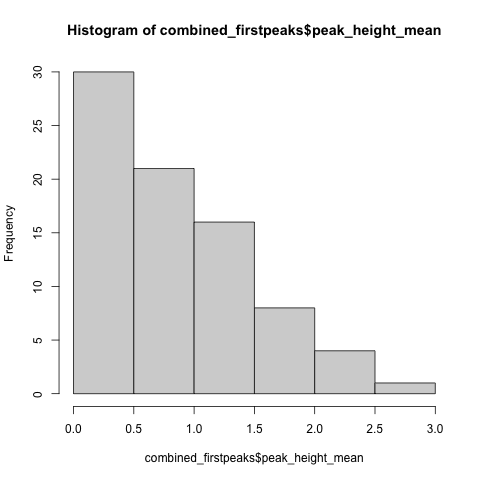

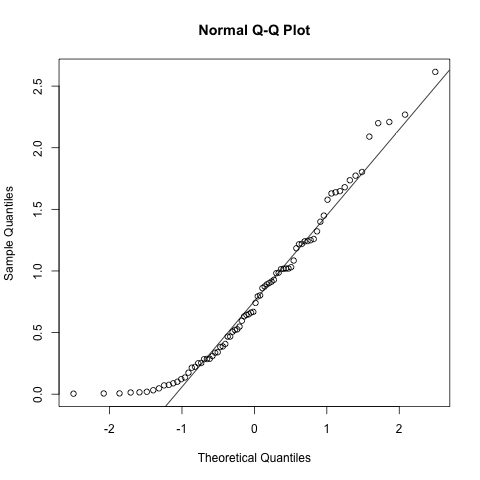

In [924]:
%%R
hist(combined_firstpeaks$peak_height_mean)
qqnorm(combined_firstpeaks$peak_height_mean)
qqline(combined_firstpeaks$peak_height_mean)

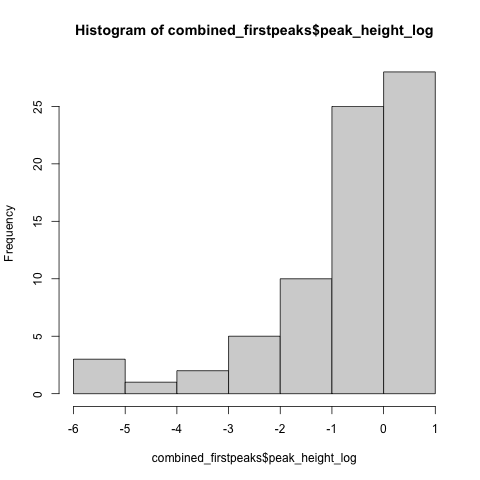

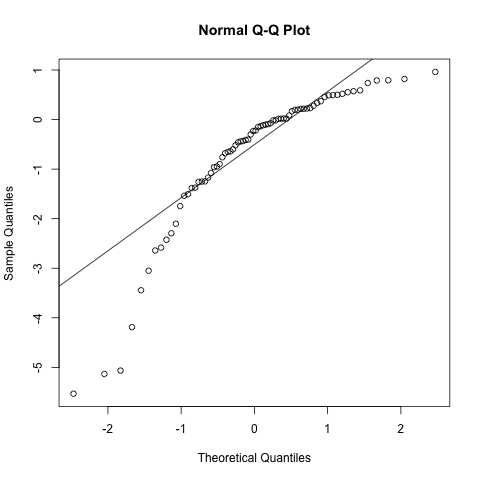

In [961]:
%%R
combined_firstpeaks$peak_height_log <- log(combined_firstpeaks$peak_height_mean)
hist(combined_firstpeaks$peak_height_log)
qqnorm(combined_firstpeaks$peak_height_log)
qqline(combined_firstpeaks$peak_height_log)

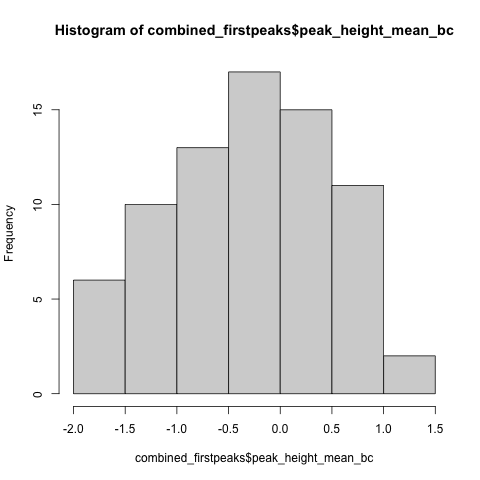

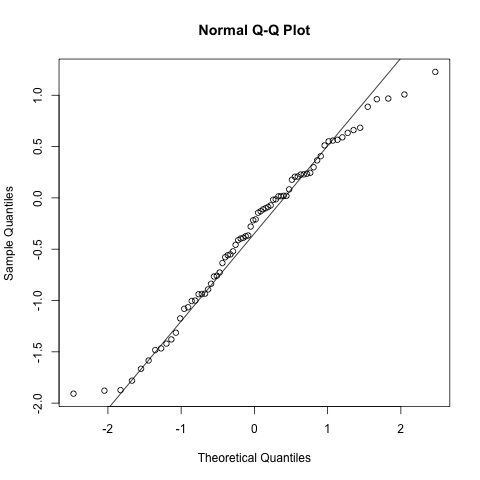

In [962]:
%%R
#Box-Cox transformation
bc_peakheight <- boxcox(combined_firstpeaks$peak_height_mean)
lambda <- bc_peakheight$lambda
combined_firstpeaks$peak_height_mean_bc <- (combined_firstpeaks$peak_height_mean^lambda - 1) / lambda
hist(combined_firstpeaks$peak_height_mean_bc)
qqnorm(combined_firstpeaks$peak_height_mean_bc)
qqline(combined_firstpeaks$peak_height_mean_bc)

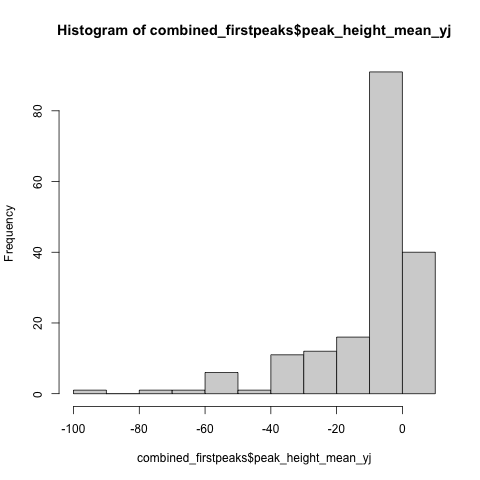

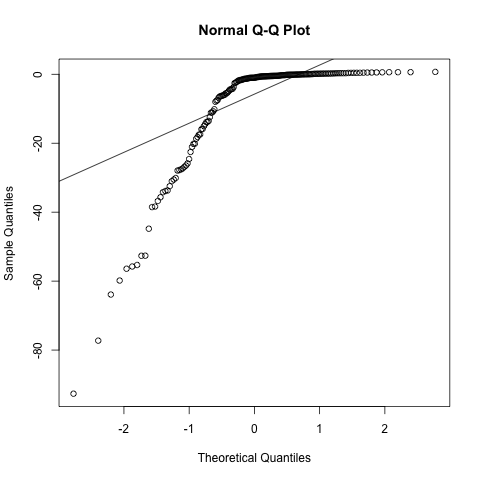

In [749]:
%%R
#Yeo-Johnson transformation
yj_peakheight <- yeojohnson(combined_firstpeaks$peak_height_mean)
lambda <- yj_peakheight$lambda
combined_firstpeaks$peak_height_mean_yj <- (combined_firstpeaks$peak_height_mean^lambda - 1) / lambda
hist(combined_firstpeaks$peak_height_mean_yj)
qqnorm(combined_firstpeaks$peak_height_mean_yj)
qqline(combined_firstpeaks$peak_height_mean_yj)

## Fit and evaluate your model
Deciding on a "good" model can be tricky. Always ask a biostatistician if you're confused! <br>
<b>The following models are specifically for bayesian generalized linear mixed models! This may not be the type of model you want for YOUR analysis </b>
You want to decide on the distribution that best describes your data (e.g., gaussian, student, lognormal, etc.) <br>
Then, do model checks such as pp checks, outlier analysis, and normality of random effects. Play around with the different models and pick the one that seems to fit your data the best. 

In [963]:
%%R

peakheight_student <- brms::brm(peak_height_mean_bc ~ treatment * condition + (1|subject) + (1|subject:cell), 
                                data = combined_firstpeaks,
                                family = student,
                                prior = c(
                                    prior(normal(0, 0.5), class = b),
                                    prior(normal(0, 0.5), class = Intercept),
                                    prior(exponential(2), class = sd)
                                ),
                                save_pars = save_pars(all=TRUE),
                                chains = 4, 
                                iter = 6000, warmup = 1000, seed = 123, control = list(adapt_delta=0.98))


SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 7.5e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.75 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 6000 [  0%]  (Warmup)
Chain 1: Iteration:  600 / 6000 [ 10%]  (Warmup)
Chain 1: Iteration: 1001 / 6000 [ 16%]  (Sampling)
Chain 1: Iteration: 1600 / 6000 [ 26%]  (Sampling)
Chain 1: Iteration: 2200 / 6000 [ 36%]  (Sampling)
Chain 1: Iteration: 2800 / 6000 [ 46%]  (Sampling)
Chain 1: Iteration: 3400 / 6000 [ 56%]  (Sampling)
Chain 1: Iteration: 4000 / 6000 [ 66%]  (Sampling)
Chain 1: Iteration: 4600 / 6000 [ 76%]  (Sampling)
Chain 1: Iteration: 5200 / 6000 [ 86%]  (Sampling)
Chain 1: Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain 1: Iteration: 6000 / 6000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.544 seconds (Warm-up)
Chain 1:                1.156 seconds (Sampling)
Chain 1:            

Compiling Stan program...
Start sampling
In addition: Warning messages:
1: There were 4 divergent transitions after warmup. See
https://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup
to find out why this is a problem and how to eliminate them. 
2: Examine the pairs() plot to diagnose sampling problems
 


In [966]:
%%R

#another model you could try...
peakheight_gauss <- brms::brm(peak_height_mean_bc ~ treatment * condition + (1|subject) + (1|subject:cell),
                            data=combined_firstpeaks, 
                            family = gaussian,
                            prior = c(
                                prior(normal(0, 0.5), class = b), 
                                prior(normal(0, 0.5), class = Intercept),
                                prior(exponential(2), class = sd)
                            ),
                            save_pars = save_pars(all = TRUE),
                            chains = 4,
                           iter = 6000, warmup = 1000, seed=123, control = list(adapt_delta=0.98))


SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 9.9e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.99 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 6000 [  0%]  (Warmup)
Chain 1: Iteration:  600 / 6000 [ 10%]  (Warmup)
Chain 1: Iteration: 1001 / 6000 [ 16%]  (Sampling)
Chain 1: Iteration: 1600 / 6000 [ 26%]  (Sampling)
Chain 1: Iteration: 2200 / 6000 [ 36%]  (Sampling)
Chain 1: Iteration: 2800 / 6000 [ 46%]  (Sampling)
Chain 1: Iteration: 3400 / 6000 [ 56%]  (Sampling)
Chain 1: Iteration: 4000 / 6000 [ 66%]  (Sampling)
Chain 1: Iteration: 4600 / 6000 [ 76%]  (Sampling)
Chain 1: Iteration: 5200 / 6000 [ 86%]  (Sampling)
Chain 1: Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain 1: Iteration: 6000 / 6000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.322 seconds (Warm-up)
Chain 1:                1.573 seconds (Sampling)
Chain 1:            

Compiling Stan program...
Start sampling
In addition: Warning messages:
1: There were 2 divergent transitions after warmup. See
https://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup
to find out why this is a problem and how to eliminate them. 
2: Examine the pairs() plot to diagnose sampling problems
 


## Check your model(s) 
You can uncomment and try some of the following checks. Read more about them in the loo and bayesplot packages

In addition: Warning message:
Found 1 observations with a pareto_k > 0.7 in model 'peakheight_gauss'. We recommend to set 'moment_match = TRUE' in order to perform moment matching for problematic observations.  


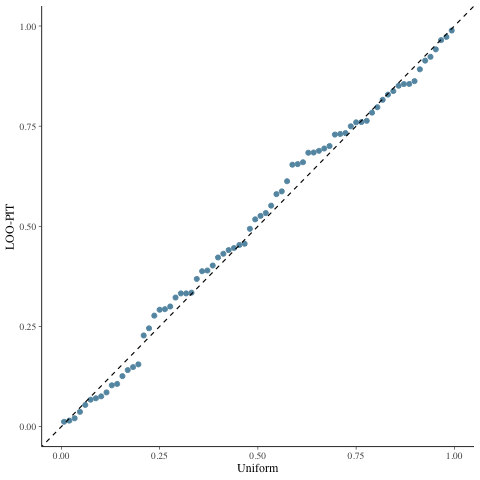

In [983]:
%%R

# Split by treatment
#p1 <- ggplot(combined_firstpeaks, 
#       aes(x = peak_height_mean_bc, fill = treatment)) +
#    geom_density(alpha = 0.5) +
#    facet_wrap(~ condition) +
#    theme_classic()
#p1

# Split by subject
#p2 <- ggplot(combined_firstpeaks,
#       aes(x = peak_height_mean_bc, fill = subject)) +
#    geom_density(alpha = 0.5) +
#    facet_wrap(~ subject) +
#    theme_classic()
#p2

# Split by condition
#p3 <- ggplot(combined_firstpeaks,
#    aes(x = peak_height_mean_bc, fill = condition)) +
#    geom_density(alpha = 0.5) +
#    facet_wrap(~ treatment) + 
#    theme_classic()
#p3

# Check R-hat — should be as close to 1.00 for all parameters
#summary(peakheight_gauss)

# Check trace plots — chains should mix well

#plot(peakheight_student)

#pp_check(peakheight_gauss, ndraws = 50)
#check_model(peakheight_gauss, check=c("pp_check", "reqq", "outliers", "homogeneity"))
#pp_check(peakheight_gauss, type = "ecdf_overlay")
#pp_check(peakheight_gauss, type = "stat")
#pp_check(peakheight_student, type = "error_hist")
#peakheight_gauss_loo <- loo(peakheight_gauss, save_psis=TRUE, k_threshold = 0.7)
#plot(peakheight_student_loo, label_points=TRUE)
#yrep <- posterior_predict(peakheight_gauss)
#ppc_loo_pit_qq(combined_firstpeaks$peak_height_mean_bc, yrep, lw = weights(peakheight_gauss_loo$psis_object)) 
#loo(peakheight_student, moment_match=TRUE)

#if you have multiple models and want to compare which one is the best, uncomment below:
#loo(peakheight_student, peakheight_gauss, compare=TRUE, moment_match = TRUE)

In [989]:
%%R
emm <- emmeans(peakheight_student, ~ treatment | condition)

contrast(emm, method="pairwise")
emm_df <- as.data.frame(emm)
emm_df$treatment <- factor(emm_df$treatment, levels=c("pre", "post"))
emm_contrasts_df <- as.data.frame(contrast(emm, method="pairwise", adjust="sidak"))
emm_contrasts_df
#emm_df

condition = Control:
 contrast     estimate  lower.HPD  upper.HPD
 post - pre -0.9712114 -1.4606285 -0.4904635

condition = GDNF:
 contrast     estimate  lower.HPD  upper.HPD
 post - pre -0.5086610 -0.7916959 -0.2202806

Point estimate displayed: median 
HPD interval probability: 0.95 


In [1146]:
%%R
pd <- p_direction(peakheight_student)
print(pd)
hypothesis(peakheight_student, "treatmentpre:conditionGDNF < 0")

Probability of Direction

Parameter                  |     pd
-----------------------------------
(Intercept)                | 99.48%
treatmentpre               | 99.99%
conditionGDNF              | 77.19%
treatmentpre:conditionGDNF | 95.36%
Hypothesis Tests for class b:
                Hypothesis Estimate Est.Error CI.Lower CI.Upper Evid.Ratio
1 (treatmentpre:con... < 0    -0.46      0.27    -0.89    -0.01      20.53
  Post.Prob Star
1      0.95    *
---
'CI': 90%-CI for one-sided and 95%-CI for two-sided hypotheses.
'*': For one-sided hypotheses, the posterior probability exceeds 95%;
for two-sided hypotheses, the value tested against lies outside the 95%-CI.
Posterior probabilities of point hypotheses assume equal prior probabilities.


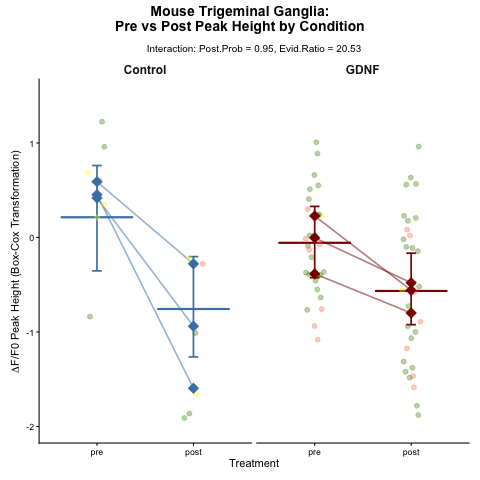

In [995]:
%%R
library(ggplot2)
library(dplyr)
library(patchwork)  # for side by side panels
library(tidybayes)
library(ggsignif)
options(scipen=0)

emm_df <- as.data.frame(emm)
emm_df$treatment <- factor(emm_df$treatment, levels = c("pre", "post"))

# Get posterior draws for ribbon
post_draws <- peakheight_student %>% #this variable may need to be changed
    epred_draws(newdata = expand.grid(
        treatment = c("pre", "post"),
        condition = c("Control", "GDNF"),
        file = NA,
        cell = NA
    ), re_formula = NA)  # population level only


# Summarise draws
post_summary <- post_draws %>%
    group_by(treatment, condition) %>%
    summarise(mean = mean(.epred), 
            lower = quantile(.epred, 0.025),
            upper = quantile(.epred, 0.975),
            .groups = "drop")

weighted_means <- emm_df %>%
  dplyr::select(treatment, condition, emmean, lower.HPD, upper.HPD) %>%
  dplyr::rename(mean = emmean,
         lower = lower.HPD,
         upper = upper.HPD)
                

post_summary$treatment <- factor(post_summary$treatment, levels = c("pre", "post"))

# Per cell data — pre and post only
df_prepost <- combined_firstpeaks[combined_firstpeaks$treatment %in% c("pre", "post"), ]
df_prepost$treatment <- factor(df_prepost$treatment, levels = c("pre", "post"))

# Per animal means
animal_means <- df_prepost %>%
    group_by(subject, treatment, condition, stim_idx) %>%
    summarise(mean_peakheight_bc = mean(peak_height_mean_bc), #this variable may need to be changed 
              .groups = "drop")

n_subjects <- length(unique(combined_firstpeaks$subject))
    
# Plot function to avoid repeating code
make_plot <- function(data, animal_data, post_data, y_var, y_label) {
    ggplot() +
        # Individual cell points
    geom_boxplot(data = post_data,
                 aes(x = treatment, y = mean, color = condition),
                 alpha = 0.5, outlier.shape = NA) +
            geom_errorbar(data = post_data,
                      aes(x = treatment, ymin = lower, ymax = upper, color = condition),
                      alpha=1, width = 0.1, linewidth = 0.8) +
    #facet_wrap(~ condition) + 
            geom_line(data = animal_data,
                  aes(x = treatment, y = .data[[y_var]], 
                      group = interaction(subject, condition),
                      color = condition),
                  linewidth = 0.8, alpha=0.5) +
            geom_jitter(data = data,
                    aes(x = treatment, y = .data[[y_var]], colour = subject),
                    width = 0.1, alpha = 0.35, size = 2) +
            # Per animal means
        geom_point(data=animal_data,
                   aes(x = treatment, y = .data[[y_var]], colour= condition),
                   alpha=1, position=position_dodge(width=1),
                   size=5, shape=18) + 
    #annotate("segment", x = 1, xend = 2,
    #         y = max_y + 0.1, yend = max_y + 0.1) +
   #annotate("text", x = 1.5, y = max_y ,
    #         label = paste0("p = ", contrasts_df$p.value[1],2)) +
            # Model estimated mean
        #geom_boxplot(data = post_data,
        #           aes(x = treatment, y = mean),
        #           colour = "black", size = 3, shape = 16,
        #           position = position_nudge(x = 0.2)) +
        # 95% credible interval
        # Line connecting model estimates
       # geom_line(data = post_data,
       #           aes(x = as.numeric(treatment) + 0.2, y = mean, group = condition),
       #           colour = "black", linewidth = 0.8, linetype = "dashed") +
        scale_colour_manual(values=c("Control" = "steelblue", 
                                        "GDNF" = "darkred",
                                        #"WT8" = "cyan4",
                                        "WT7" = "yellow",
                                        "WT1" = "chartreuse4",
                                        #"WT6" = "mediumvioletred",
                                        #"NMR107" = "deeppink3", 
                                       "WT2" = "coral")) + 
        # p-value per facet using geom_text
       # geom_text(data = p_annotations,
       #           aes(x = 1.5, y = y , label = label),
       #          size = 3.5, hjust = 0.5) +
        # significance bracket per facet
        #geom_bracket(data = p_annotations,
        #             aes(xmin = 1, xmax= 2,
        #                 y = y * 0.98, yend = y * 0.98)) + 
        facet_wrap(~ condition) +
        labs(x = "Treatment", y = y_label) +
        theme_classic() + 
        theme(legend.position = "none",strip.background = element_blank(),strip.text = element_text(size = 12, face = "bold"))
}

# Raw dff panel
#p1 <- make_plot(df_prepost, 
#                animal_means %>% rename(peak_height_mean = mean_dff),
#                 post_data = post_summary[post_summary$condition == "Control" | 
#                             post_summary$condition == "GDNF", ]
#                y_var = "peak_height_mean", 
#                y_label = "ΔF/F0")

# Box-Cox transformed panel
p2 <- make_plot(df_prepost %>% rename(peak_height_mean_bc = peak_height_mean_bc),
                animal_means %>% rename(peak_height_mean_bc = mean_peakheight_bc),
                post_data = weighted_means,
                y_var = "peak_height_mean_bc",
                y_label = expression(Delta * "F/F0 Peak Height (Box-Cox Transformation)"))

#add stats; YOU WILL HAVE TO ENTER THESE MANUALLY!
p2 <- p2 + labs(subtitle = "Interaction: Post.Prob = 0.95, Evid.Ratio = 20.53") + #MAKE SURE YOU CHANGE THIS ACCORDINGLY!!!!!
         theme(plot.subtitle = element_text(hjust = 0.5, size = 10)) + coord_cartesian(ylim = c(-2, 1.5))

# Combine side by side
p2 <- p2 + plot_layout(guides = "collect") + plot_annotation(title = "Mouse Trigeminal Ganglia:\nPre vs Post Peak Height by Condition",
                   theme = theme(plot.title = element_text(size = 14, 
                                                           face = "bold",
                                                            hjust = 0.5)))
plot(p2)
ggsave(file.path(output_dir, "MouseTG_PeakHeight_BoxCoxTransformation_Student_Plot.pdf"), width = 8, height = 7)